# Árvores II - Tarefa I

### 1. Carregar a base



In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import os
import numpy as np
import matplotlib.pyplot as plt

# Caminho onde estão os arquivos
caminho = r'C:\Users\miler\Desktop\EBACK- Miler\modulo 17'

# Carregar features.txt em uma Series
features = pd.read_csv(
    os.path.join(caminho, 'features.txt'),
    sep=r'\s+',
    header=None,
    usecols=[1]
).squeeze()

# Colunas que serão usadas no exercício
colunas = [
    'tBodyAcc-mean()-X',
    'tBodyAcc-mean()-Y',
    'tBodyAcc-mean()-Z'
]

# -------------------------
# Base de treino
# -------------------------

subject_train = pd.read_csv(
    os.path.join(caminho, 'subject_train.txt'),
    header=None
).squeeze()

X_train = pd.read_csv(
    os.path.join(caminho, 'X_train.txt'),
    sep=r'\s+',
    header=None
)

X_train.columns = features
X_train = X_train[colunas]

X_train['sujeito'] = subject_train
X_train['ordem'] = X_train.index
X_train = X_train.set_index(['ordem', 'sujeito'])

y_train = pd.read_csv(
    os.path.join(caminho, 'y_train.txt'),
    header=None
).squeeze()

# -------------------------
# Base de teste
# -------------------------

subject_test = pd.read_csv(
    os.path.join(caminho, 'subject_test.txt'),
    header=None
).squeeze()

X_test = pd.read_csv(
    os.path.join(caminho, 'X_test.txt'),
    sep=r'\s+',
    header=None
)

X_test.columns = features
X_test = X_test[colunas]

X_test['sujeito'] = subject_test
X_test['ordem'] = X_test.index
X_test = X_test.set_index(['ordem', 'sujeito'])

y_test = pd.read_csv(
    os.path.join(caminho, 'y_test.txt'),
    header=None
).squeeze()

# Salvar bases tratadas
X_train.to_csv(os.path.join(caminho, 'X_train_tratado.csv'))
X_test.to_csv(os.path.join(caminho, 'X_test_tratado.csv'))

X_train.head()



,1,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z
ordem,sujeito,,,
0,1,0.288585,-0.020294,-0.132905
1,1,0.278419,-0.016411,-0.123520
2,1,0.279653,-0.019467,-0.113462
3,1,0.279174,-0.026201,-0.123283
4,1,0.276629,-0.016570,-0.115362


### 2. Ajustar uma árvore de decisão



In [8]:
%%time

# 2.1 Ajustar árvore usando apenas as 3 variáveis
arvore = DecisionTreeClassifier(
    min_samples_leaf=20,
    random_state=123
)

arvore.fit(X_train, y_train)

# 2.2 Calcular os ccp_alphas
caminho_poda = arvore.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = caminho_poda.ccp_alphas

# Selecionar apenas valores positivos e únicos
ccp_alphas = ccp_alphas[ccp_alphas > 0]
ccp_alphas = np.unique(ccp_alphas)

# 2.3 Pegar apenas 1 a cada 5 valores
ccp_alphas = ccp_alphas[::5]

ccp_alphas

CPU times: total: 109 ms
Wall time: 87.5 ms


array([6.96674540e-06, 4.63397246e-05, 6.73768888e-05, 8.28222484e-05,
       1.02953015e-04, 1.20580361e-04, 1.41963138e-04, 1.51968146e-04,
       1.67323005e-04, 1.81439304e-04, 1.96526409e-04, 2.03119333e-04,
       2.05888258e-04, 2.11960464e-04, 2.26826797e-04, 2.39444770e-04,
       2.47932477e-04, 2.52885177e-04, 2.62495937e-04, 2.73408734e-04,
       2.83037295e-04, 2.87980319e-04, 3.13171720e-04, 3.26787621e-04,
       3.51668945e-04, 3.73564446e-04, 3.99220300e-04, 4.29862753e-04,
       4.51528412e-04, 4.63079099e-04, 4.87208882e-04, 5.11794978e-04,
       5.25732429e-04, 5.56286552e-04, 6.37883381e-04, 7.02050790e-04,
       7.53735819e-04, 8.64950391e-04, 9.29376560e-04, 1.13240843e-03,
       1.24197638e-03, 1.65230695e-03, 2.18765587e-03, 2.66788979e-03,
       3.13001880e-03, 4.73006126e-03, 1.05395082e-02])

### 3. Desempenho da árvore por ccp_alpha


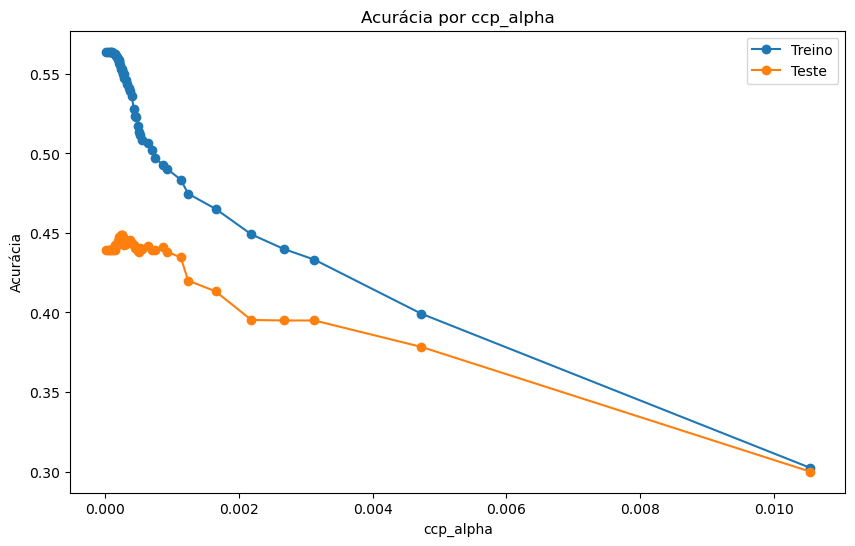

Melhor ccp_alpha: 0.00023944476959803082
Melhor acurácia com as três variáveis: 0.44859178825924667
CPU times: total: 1.59 s
Wall time: 1.6 s


,ccp_alpha,train_score,test_score
0,0.000007,0.564064,0.439430
1,0.000046,0.564064,0.439430
2,0.000067,0.564064,0.439430
3,0.000083,0.564064,0.439430
4,0.000103,0.563656,0.440109
5,0.000121,0.563112,0.439091
6,0.000142,0.562704,0.439091
7,0.000152,0.562296,0.442484
8,0.000167,0.561480,0.442145
9,0.000181,0.560800,0.442145


In [11]:
%%time

# 3.1 Rodar uma árvore para cada ccp_alpha e salvar em uma lista
arvores = []

for ccp_alpha in ccp_alphas:
    arvore = DecisionTreeClassifier(
        min_samples_leaf=20,
        random_state=123,
        ccp_alpha=ccp_alpha
    )
    
    arvore.fit(X_train, y_train)
    arvores.append(arvore)


# 3.2 Calcular a acurácia de cada árvore na base de treino e teste
train_scores = []
test_scores = []

for arvore in arvores:
    train_scores.append(arvore.score(X_train, y_train))
    test_scores.append(arvore.score(X_test, y_test))


# Criar tabela com os resultados
resultado = pd.DataFrame({
    'ccp_alpha': ccp_alphas,
    'train_score': train_scores,
    'test_score': test_scores
})


# 3.3 Gráfico da acurácia em função do ccp_alpha
plt.figure(figsize=(10, 6))

plt.plot(resultado['ccp_alpha'], resultado['train_score'], marker='o', label='Treino')
plt.plot(resultado['ccp_alpha'], resultado['test_score'], marker='o', label='Teste')

plt.xlabel('ccp_alpha')
plt.ylabel('Acurácia')
plt.title('Acurácia por ccp_alpha')
plt.legend()
plt.show()


# 3.4 Selecionar a melhor árvore pela acurácia na base de teste
melhor_indice = resultado['test_score'].idxmax()

melhor_arvore = arvores[melhor_indice]
melhor_ccp_alpha = resultado.loc[melhor_indice, 'ccp_alpha']
melhor_acuracia = resultado.loc[melhor_indice, 'test_score']


# 3.5 Melhor acurácia obtida com as três variáveis
print('Melhor ccp_alpha:', melhor_ccp_alpha)
print('Melhor acurácia com as três variáveis:', melhor_acuracia)

resultado